# Financial Behavior Segmentation  
## A Python-Based Statistical Analysis Using Synthetic Survey Data

This project analyzes financial behavior among young adults using synthetic survey and spending data.

The goal is to segment users based on spending psychology, savings discipline, impulse buying, stress spending, and budgeting habits.

**Target group:** Young adults aged 18 to 35.

# 👨💻 Author

| Name | Role | GitHub |
| :--- | :--- | :--- |
| **Sanman Kadam** | Aspiring Data Analyst | [![GitHub](https://img.shields.io/badge/GitHub-100000?style=for-the-badge&logo=github&logoColor=white)](https://github.com/the-irritater) |

## 📊 Project Information

| Field | Details |
| :--- | :--- |
| **Project Type** | Data Analytics Portfolio Project |
| **Dataset Type** | Synthetic financial behavior survey data |
| **Analysis Focus** | Hypothesis testing, regression, PCA, and K-Means clustering |
| **Tools Used** | Python, pandas, seaborn, scipy, statsmodels, scikit-learn |
| **Last Updated** | April 2026 |

## Problem Statement

Many young adults struggle with savings, impulse spending, and irregular budgeting. Banks, fintech companies, and personal finance platforms need to understand user behavior so they can design better financial guidance, budget alerts, and personalized saving recommendations.

This project uses statistical analysis and clustering to identify meaningful financial behavior segments.

## Research Questions

1. Are impulse buying and stress spending related to lower savings rates?
2. Does financial literacy improve savings discipline and budgeting habits?
3. Do savings rates differ across employment groups?
4. Can users be grouped into meaningful financial behavior segments?

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

In [25]:
df = pd.read_csv("synthetic_financial_behavior_data.csv")
df.head()

,participant_id,age,gender,employment_status,city_tier,monthly_income,FL1,FL2,FL3,FL4,FL5,IB1,IB2,IB3,IB4,IB5,SS1,SS2,SS3,SS4,SD1,SD2,SD3,SD4,SD5,BH1,BH2,BH3,BH4,essential_expenses,discretionary_expenses,monthly_savings,debt_payment,total_expenses,savings_rate,expense_to_income_ratio,financial_literacy_score,impulse_buying_score,stress_spending_score,saving_discipline_score,budgeting_habit_score
0,FB0001,20,Male,Student,Tier 2,81535.0,4.0,5.0,4.0,3.0,4.0,1.0,2.0,1.0,2.0,2.0,3.0,4.0,3.0,3.0,4.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,25441.0,3347.0,27331.0,0.0,28788.0,0.335,0.353,4.0,1.6,3.25,3.6,4.00
1,FB0002,23,Female,Full-time Employee,Tier 3,120000.0,4.0,4.0,4.0,2.0,3.0,2.0,3.0,3.0,2.0,3.0,3.0,1.0,3.0,2.0,1.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,1.0,36150.0,15816.0,3532.0,3235.0,55201.0,0.029,0.460,3.4,2.6,2.25,1.2,1.75
2,FB0003,34,Male,Student,Tier 2,108493.0,3.0,2.0,1.0,3.0,2.0,5.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,3.0,2.0,2.0,3.0,2.0,2.0,1.0,2.0,3.0,40645.0,39525.0,4572.0,14471.0,94641.0,0.042,0.872,2.2,4.6,4.75,2.4,2.00
3,FB0004,19,Male,Student,Tier 1,120000.0,3.0,3.0,3.0,4.0,3.0,1.0,2.0,2.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,4.0,4.0,3.0,4.0,3.0,4.0,3.0,4.0,65340.0,7931.0,38228.0,4739.0,78010.0,0.319,0.650,3.2,2.0,2.25,3.8,3.50
4,FB0005,24,Female,Student,Tier 1,118834.0,4.0,3.0,4.0,3.0,3.0,2.0,3.0,2.0,3.0,3.0,4.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,2.0,4.0,3.0,4.0,2.0,44645.0,16100.0,25515.0,4440.0,65185.0,0.215,0.549,3.4,2.6,3.50,2.8,3.25


**Interpretation:**  
The dataset contains demographic variables, income and expense variables, Likert-scale survey items, and composite behavioral scores.

**Business Insight:**  
Having a rich set of demographic and behavioral data enables precise segmentation, which is critical for personalized financial product recommendations.

In [26]:
df.shape

(600, 41)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            600 non-null    str    
 1   age                       600 non-null    int64  
 2   gender                    600 non-null    str    
 3   employment_status         600 non-null    str    
 4   city_tier                 600 non-null    str    
 5   monthly_income            600 non-null    float64
 6   FL1                       593 non-null    float64
 7   FL2                       595 non-null    float64
 8   FL3                       592 non-null    float64
 9   FL4                       596 non-null    float64
 10  FL5                       596 non-null    float64
 11  IB1                       592 non-null    float64
 12  IB2                       595 non-null    float64
 13  IB3                       597 non-null    float64
 14  IB4                  

## Data Cleaning

In [28]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

IB4    9
IB1    8
SS3    8
SS1    8
FL3    8
IB5    7
SS2    7
FL1    7
BH3    6
SD4    5
IB2    5
SD1    5
FL2    5
FL5    4
FL4    4
BH2    4
SS4    4
SD3    3
SD5    3
IB3    3
BH4    2
BH1    2
SD2    2
dtype: int64

**Interpretation:**  
The dataset contains small item-level missing values, which is realistic for survey data. Composite scores were calculated using available item responses, so participants are retained.

**Business Insight:**  
Data imputation and handling missing values correctly ensures that no valuable behavioral signal is lost, maximizing the reach of our insights.

In [29]:
df.duplicated().sum()

np.int64(0)

**Interpretation:**  
Duplicate records should be checked before analysis. Duplicate participant rows can distort averages, hypothesis tests, and clustering results.

**Business Insight:**  
Data integrity is paramount in behavioral analytics. Clean data ensures our recommendations are based on actual distinct user behaviors.

## Descriptive Statistics

In [30]:
score_cols = [
    "financial_literacy_score",
    "impulse_buying_score",
    "stress_spending_score",
    "saving_discipline_score",
    "budgeting_habit_score",
    "savings_rate",
    "expense_to_income_ratio"
]

df[["age", "monthly_income", "essential_expenses", "discretionary_expenses", 
    "monthly_savings", "debt_payment"] + score_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,600.0,24.658333,4.739448,18.000,20.000,24.000,28.00000,35.000
monthly_income,600.0,114335.588333,14111.803025,39204.000,120000.000,120000.000,120000.00000,120000.000
essential_expenses,600.0,46802.196667,13161.463906,13136.000,37510.000,46103.000,55389.50000,83511.000
discretionary_expenses,600.0,18027.740000,8681.180520,500.000,11954.500,18140.500,23425.50000,46138.000
monthly_savings,600.0,21912.725000,11933.617235,0.000,12710.750,22257.000,30422.50000,52455.000
debt_payment,600.0,6032.041667,4969.430699,0.000,1879.000,5295.500,9185.75000,23818.000
financial_literacy_score,600.0,3.160083,0.807314,1.000,2.600,3.200,3.80000,5.000
impulse_buying_score,600.0,3.090222,0.824179,1.000,2.600,3.000,3.60000,5.000
stress_spending_score,600.0,2.870972,0.945097,1.000,2.250,2.750,3.50000,5.000
saving_discipline_score,600.0,3.096500,0.894411,1.000,2.600,3.000,3.80000,5.000


**Interpretation:**  
This table gives the central tendency and spread of income, expenses, savings, and behavioral scores. For Likert-based scores, values closer to 5 indicate stronger presence of that behavior.

## Reliability Testing: Cronbach's Alpha

In [31]:
def cronbach_alpha(items_df):
    items_df = items_df.dropna()
    item_variances = items_df.var(axis=0, ddof=1)
    total_score = items_df.sum(axis=1)
    n_items = items_df.shape[1]
    total_variance = total_score.var(ddof=1)
    alpha = (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha

reliability = pd.DataFrame({
    "Scale": [
        "Financial Literacy",
        "Impulse Buying",
        "Stress Spending",
        "Saving Discipline",
        "Budgeting Habit"
    ],
    "Cronbach Alpha": [
        cronbach_alpha(df[[f"FL{i}" for i in range(1, 6)]]),
        cronbach_alpha(df[[f"IB{i}" for i in range(1, 6)]]),
        cronbach_alpha(df[[f"SS{i}" for i in range(1, 5)]]),
        cronbach_alpha(df[[f"SD{i}" for i in range(1, 6)]]),
        cronbach_alpha(df[[f"BH{i}" for i in range(1, 5)]])
    ]
})

reliability

,Scale,Cronbach Alpha
0,Financial Literacy,0.884644
1,Impulse Buying,0.896103
2,Stress Spending,0.902985
3,Saving Discipline,0.913668
4,Budgeting Habit,0.883929


**Interpretation:**  
Cronbach's Alpha checks internal consistency of each survey scale. A value above 0.70 is usually acceptable for exploratory analysis, while values above 0.80 indicate stronger reliability.

## Exploratory Data Analysis

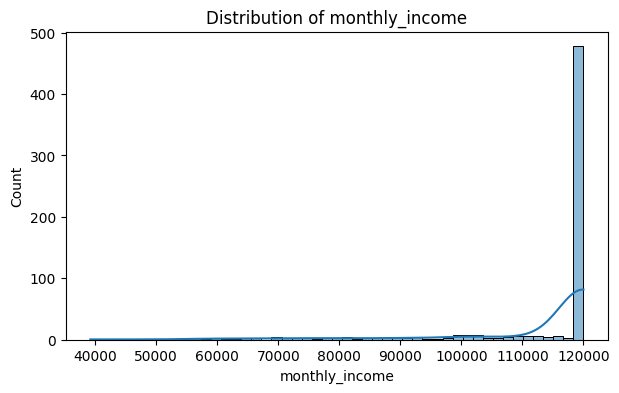

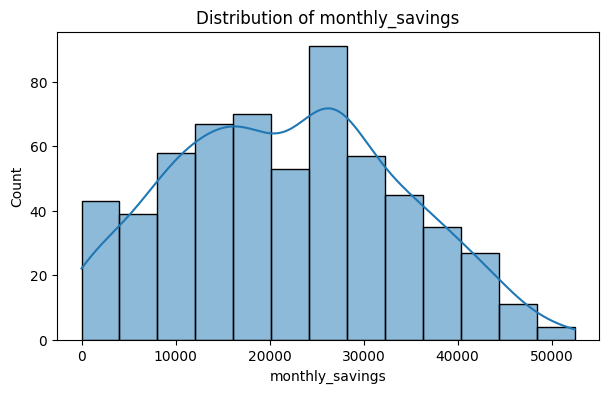

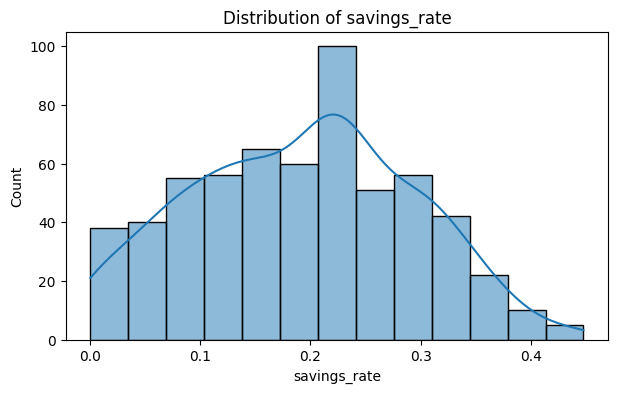

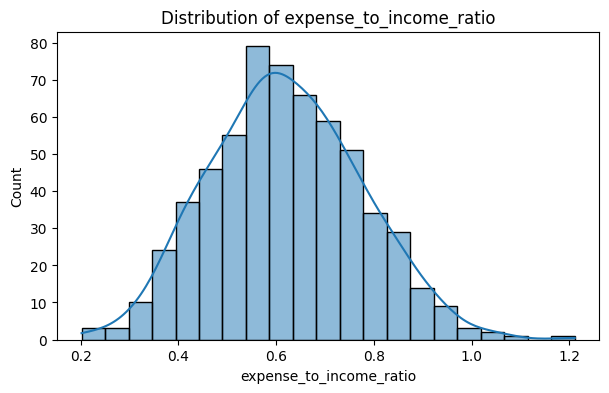

In [32]:
for col in ["monthly_income", "monthly_savings", "savings_rate", "expense_to_income_ratio"]:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**Interpretation:**  
These plots show the spread of income, savings, savings rate, and expense pressure. Skewness is expected because income and spending behavior are rarely normally distributed.

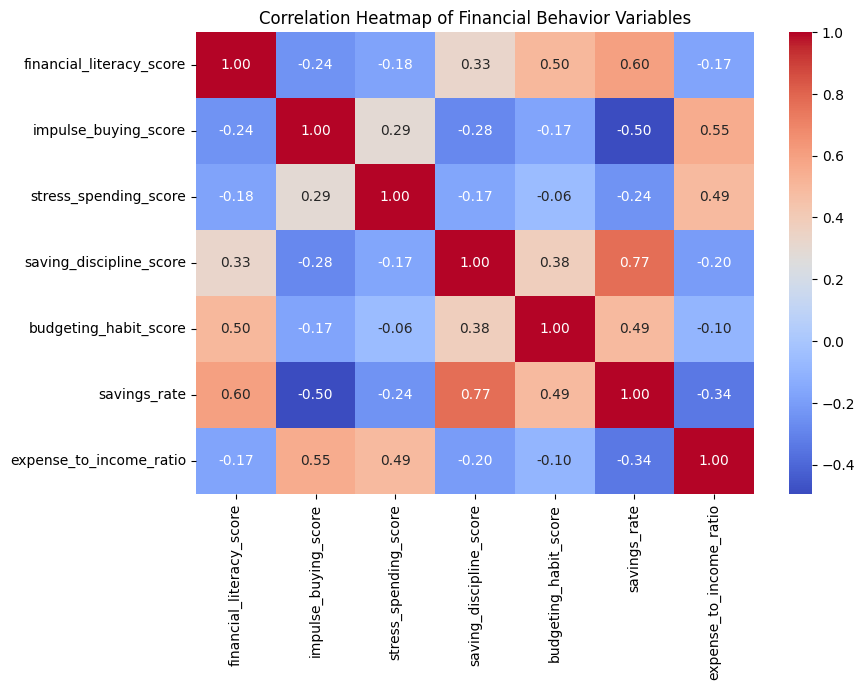

In [33]:
plt.figure(figsize=(9, 6))
corr = df[score_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Financial Behavior Variables")
plt.show()

**Interpretation:**  
The heatmap shows relationships among financial literacy, impulse buying, stress spending, savings discipline, budgeting habits, savings rate, and expense-to-income ratio.

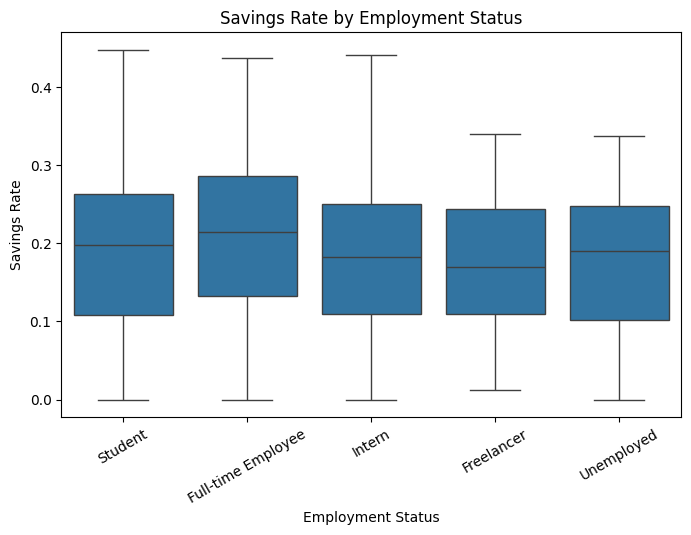

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="employment_status", y="savings_rate")
plt.xticks(rotation=30)
plt.title("Savings Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Savings Rate")
plt.show()

**Interpretation:**  
This plot compares savings behavior across employment groups. Full-time employees may show different savings capacity compared with students or interns because income stability differs.

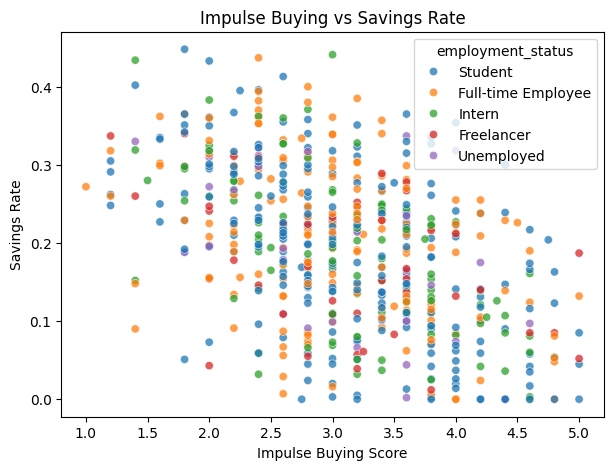

In [35]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="impulse_buying_score", y="savings_rate", hue="employment_status", alpha=0.75)
plt.title("Impulse Buying vs Savings Rate")
plt.xlabel("Impulse Buying Score")
plt.ylabel("Savings Rate")
plt.show()

**Interpretation:**  
A downward pattern would suggest that higher impulse buying is associated with lower savings rate.

## Hypothesis Testing

### Test 1: Correlation Between Impulse Buying and Savings Rate

**H0:** Impulse buying is not related to savings rate.  
**H1:** Impulse buying is significantly related to savings rate.

In [36]:
r, p = stats.pearsonr(df["impulse_buying_score"], df["savings_rate"])
print(f"Pearson correlation: {r:.3f}")
print(f"P-value: {p:.5f}")

Pearson correlation: -0.495
P-value: 0.00000


**Interpretation:**  
If the p-value is below 0.05, impulse buying has a statistically significant relationship with savings rate. A negative correlation means higher impulse buying is associated with lower savings.

### Test 2: Correlation Between Financial Literacy and Budgeting Habit

**H0:** Financial literacy is not related to budgeting habit.  
**H1:** Financial literacy is significantly related to budgeting habit.

In [37]:
r, p = stats.pearsonr(df["financial_literacy_score"], df["budgeting_habit_score"])
print(f"Pearson correlation: {r:.3f}")
print(f"P-value: {p:.5f}")

Pearson correlation: 0.501
P-value: 0.00000


**Interpretation:**  
A significant positive correlation indicates that financially literate users are more likely to follow budgeting habits.

### Test 3: ANOVA for Savings Rate Across Employment Status

**H0:** Average savings rate is the same across employment groups.  
**H1:** At least one employment group has a different average savings rate.

In [38]:
groups = [group["savings_rate"].dropna() for _, group in df.groupby("employment_status")]
f_stat, p_val = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_val:.5f}")

df.groupby("employment_status")["savings_rate"].mean().sort_values(ascending=False)

F-statistic: 1.607
P-value: 0.17080


employment_status
Full-time Employee    0.208061
Student               0.187898
Unemployed            0.187125
Intern                0.183755
Freelancer            0.176830
Name: savings_rate, dtype: float64

**Interpretation:**  
If the p-value is below 0.05, savings rate differs significantly by employment status. This is useful for fintech products because financial guidance should differ for students, interns, employees, and freelancers.

## Regression Analysis

Model objective: explain savings rate using financial behavior and demographic variables.

In [39]:
model = smf.ols(
    "savings_rate ~ financial_literacy_score + impulse_buying_score + stress_spending_score + saving_discipline_score + budgeting_habit_score + age + C(gender) + C(employment_status) + C(city_tier)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           savings_rate   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     160.0
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          2.14e-189
Time:                        19:54:27   Log-Likelihood:                 998.26
No. Observations:                 600   AIC:                            -1967.
Df Residuals:                     585   BIC:                            -1901.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

**Interpretation:**  
Regression shows which factors explain savings rate after controlling for demographics. Positive coefficients increase savings rate, while negative coefficients reduce it.

## PCA: Reducing Behavioral Dimensions

In [40]:
cluster_features = [
    "financial_literacy_score",
    "impulse_buying_score",
    "stress_spending_score",
    "saving_discipline_score",
    "budgeting_habit_score",
    "savings_rate",
    "expense_to_income_ratio"
]

X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.44228551 0.20381241]
Total explained variance: 0.6460979228368482


In [41]:
pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,2.820680,-0.284552
1,-1.357551,-2.402071
2,-3.678924,1.208898
3,1.732541,-0.075962
4,0.346515,-0.013892


**Interpretation:**  
PCA compresses multiple financial behavior variables into two major components. This helps visualize user segments in a simpler two-dimensional space.

## K-Means Clustering: Financial Behavior Segments

In [42]:
silhouette_scores = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

silhouette_scores

{2: 0.24626603830362853,
 3: 0.19169244513547992,
 4: 0.18426710996748544,
 5: 0.16027221902907257,
 6: 0.1500638532755966,
 7: 0.13918819231816892}

In [43]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
print("Best k based on silhouette score:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
pca_df["cluster"] = df["cluster"]

cluster_profile = df.groupby("cluster")[cluster_features + ["monthly_income", "monthly_savings"]].mean().round(2)
cluster_profile

Best k based on silhouette score: 2


,financial_literacy_score,impulse_buying_score,stress_spending_score,saving_discipline_score,budgeting_habit_score,savings_rate,expense_to_income_ratio,monthly_income,monthly_savings
cluster,,,,,,,,,
0,2.59,3.54,3.16,2.53,2.56,0.11,0.68,114925.55,12454.83
1,3.62,2.72,2.64,3.56,3.54,0.26,0.57,113856.14,29599.05


**Interpretation:**  
The cluster profile table shows average behavior for each segment. This helps name segments such as disciplined savers, impulse spenders, financially stressed users, or high-income balanced users.

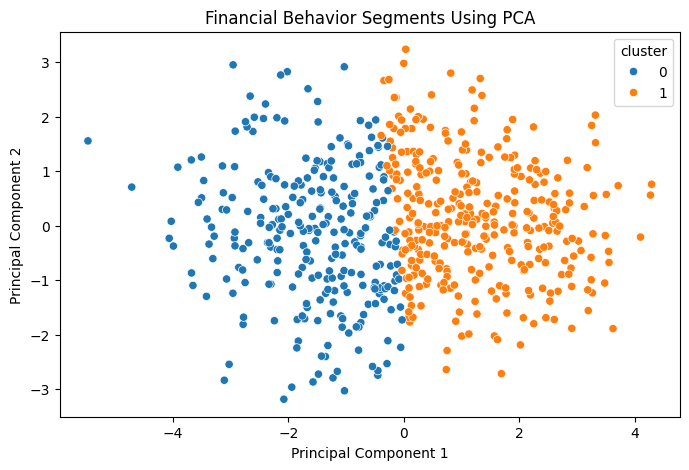

In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10")
plt.title("Financial Behavior Segments Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**Interpretation:**  
The PCA scatter plot visualizes whether clusters are reasonably separated. Clearer separation means the behavioral segments are more distinct.

## Segment Naming

In [45]:
cluster_profile

,financial_literacy_score,impulse_buying_score,stress_spending_score,saving_discipline_score,budgeting_habit_score,savings_rate,expense_to_income_ratio,monthly_income,monthly_savings
cluster,,,,,,,,,
0,2.59,3.54,3.16,2.53,2.56,0.11,0.68,114925.55,12454.83
1,3.62,2.72,2.64,3.56,3.54,0.26,0.57,113856.14,29599.05


In [46]:
# Suggested segment names based on the cluster profile.
# You can edit these names after checking your actual output.

segment_names = {}
for cluster in cluster_profile.index:
    row = cluster_profile.loc[cluster]
    if row["saving_discipline_score"] >= cluster_profile["saving_discipline_score"].mean() and row["impulse_buying_score"] <= cluster_profile["impulse_buying_score"].mean():
        segment_names[cluster] = "Disciplined Savers"
    elif row["impulse_buying_score"] >= cluster_profile["impulse_buying_score"].mean() and row["savings_rate"] <= cluster_profile["savings_rate"].mean():
        segment_names[cluster] = "Impulse Spenders"
    elif row["stress_spending_score"] >= cluster_profile["stress_spending_score"].mean() and row["expense_to_income_ratio"] >= cluster_profile["expense_to_income_ratio"].mean():
        segment_names[cluster] = "Financially Stressed Users"
    else:
        segment_names[cluster] = "Balanced Users"

df["segment_name"] = df["cluster"].map(segment_names)
df["segment_name"].value_counts()

segment_name
Disciplined Savers    331
Impulse Spenders      269
Name: count, dtype: int64

**Interpretation:**  
Segment names turn technical clusters into business-friendly groups. This is important for dashboards, stakeholder communication, and product recommendations.

## Actionable Recommendations

1. **Disciplined Savers:** Offer investment education, goal-based saving plans, and long-term wealth-building tools.  
2. **Impulse Spenders:** Provide spending alerts, category limits, and weekly budget reminders.  
3. **Financially Stressed Users:** Offer debt tracking, emergency fund guidance, and low-pressure financial education.  
4. **Balanced Users:** Recommend personalized insights, cashback optimization, and monthly financial health reports.

## Final Conclusion

This project shows how financial behavior can be analyzed using statistics, regression, PCA, and clustering.

For a Data Analyst portfolio, this project demonstrates:

- Survey data handling
- Behavioral analytics
- Financial feature engineering
- Hypothesis testing
- Regression interpretation
- Customer segmentation
- Business recommendation writing

This is not just a clustering project. It is an end-to-end financial behavior analytics case study.